In [ ]:
# Install the 'kaggle' package from PyPI using pip.
# Kaggle's platform, enabling dataset downloads directly from Kaggle servers.
!pip install kaggle

In [ ]:
# Download the 'dogs-vs-cats' dataset from Kaggle using the Kaggle CLI.
# The dataset contains labeled images of dogs and cats for training a classifier.
!kaggle datasets download -d moazeldsokyx/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/moazeldsokyx/dogs-vs-cats
License(s): CC0-1.0
dogs-vs-cats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Import Python's built-in 'zipfile' module for handling ZIP archive operations
import zipfile

# Open the downloaded ZIP file in read mode ('r').
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip','r')

# Extract all files/directories from the ZIP into '/content'.
# This creates the dataset folder structure with 'train' and 'test' subdirectories,
# each containing separate folders for 'dogs' and 'cats' images.
zip_ref.extractall('/content')

# Close the ZIP file handle to free system resources and prevent file corruption.
zip_ref.close()

In [ ]:
# Import TensorFlow — the core deep learning framework for building and training models
import tensorflow as tf

# Import Keras from TensorFlow — high-level API that simplifies neural network construction
from tensorflow import keras

# Import Sequential — allows building a neural network by stacking layers linearly
from keras import Sequential

# Import layer types needed for the CNN:
# Dense: Fully connected layer where every neuron connects to all neurons in previous layer
# Conv2D: 2D Convolutional layer that applies learnable filters to extract spatial features
# MaxPooling2D: Reduces spatial dimensions by taking max value in each pooling window
# Flatten: Converts multi-dimensional feature maps into a 1D vector for Dense layers
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten


In [ ]:
# --- Create Training and Validation Data Generators ---

# Training Dataset: Load images from directory and create a tf.data.Dataset.
# Labels are automatically inferred from subdirectory names (e.g., 'dogs/', 'cats/').
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dataset/train',  # Path to training images directory
    labels = 'inferred',       # Infer labels from subdirectory names (cats=0, dogs=1)
    label_mode = 'int',        # Encode labels as integers (0 or 1) for binary classification
    batch_size = 32,           # Load 32 images per batch during training
    image_size = (256,256)     # Resize all images to 256x256 pixels for uniform input
)

# Validation Dataset: Separate dataset for evaluating model performance after each epoch.
# This data is NOT used for training — only for monitoring overfitting.
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dataset/test',   # Path to test/validation images directory
    labels = 'inferred',       # Infer labels from subdirectory names
    label_mode = 'int',        # Integer-encoded labels
    batch_size = 32,           # 32 images per validation batch
    image_size = (256,256)     # Same 256x256 size as training images
)

Found 20000 files belonging to 2 classes.
Found 12461 files belonging to 2 classes.


In [ ]:
# Define a preprocessing function to normalize pixel values from [0,255] to [0.0,1.0].
# Normalization helps the neural network train faster and more effectively by keeping
# input values small and consistent, preventing large gradient updates.
def process(image, label):
  # Divide pixel values by 255.0 to scale from [0,255] to [0.0,1.0],
  # then cast to float32 for compatibility with model weight dtype.
  image = tf.cast(image/255. , tf.float32)
  # Return normalized image and unchanged label
  return image, label

# Apply normalization to every (image, label) pair in the training dataset
# using .map() — this creates a new dataset with all images normalized.
train_ds = train_ds.map(process)

# Apply the same normalization to validation dataset for consistent preprocessing.
validation_ds = validation_ds.map(process)

In [ ]:

# ===== Build the CNN Model Architecture =====

# Initialize a Sequential model — layers are stacked linearly, each feeding into the next.
model = Sequential()

# --- First Convolutional Block ---
# Conv2D: 32 filters of size 3x3, 'same' padding preserves spatial dimensions,
# ReLU activation introduces non-linearity (sets negatives to 0).
# input_shape=(256,256,3): expects 256x256 RGB images (3 color channels).
model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(256,256,3) ))

# MaxPooling2D: Takes max value in each 2x2 window with stride 2.
# Reduces spatial dimensions from 256x256 to 128x128 (75% parameter reduction)
# while retaining the most prominent features from each region.
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

# --- Second Convolutional Block ---
# Conv2D: 64 filters — doubled to capture more complex, higher-level patterns.
# Input: 128x128x32 -> Output: 128x128x64
model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu', ))

# MaxPooling2D: Reduces from 128x128 to 64x64 — progressive downsampling.
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

# --- Third Convolutional Block ---
# Conv2D: 128 filters — captures abstract features like ears, eyes, fur textures.
# Input: 64x64x64 -> Output: 64x64x128
model.add(Conv2D(128,kernel_size=(3,3),padding='same',activation='relu', ))

# MaxPooling2D: Reduces from 64x64 to 32x32 — compact feature representation.
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))

# --- Flatten Layer ---
# Converts 3D feature maps (32x32x128 = 131,072 values) into a 1D vector.
# Required because Dense layers expect 1D input.
model.add(Flatten())

# --- First Dense Layer: 128 neurons with ReLU ---
# Learns non-linear combinations of extracted features for classification.
model.add(Dense(128,activation='relu' ))

# --- Second Dense Layer: 64 neurons with ReLU ---
# Additional capacity to learn complex decision boundaries (128->64->1 funnel).
model.add(Dense(64,activation='relu'))

# --- Output Layer: 1 neuron with Sigmoid ---
# Sigmoid outputs a probability in [0,1]: close to 0 = Cat, close to 1 = Dog.
# Single sigmoid neuron is standard for binary classification tasks.
model.add(Dense(1,activation='sigmoid'))

In [ ]:
# Display a summary table of the model architecture showing:
# - Layer names and types
# - Output shapes at each layer
# - Number of trainable parameters (weights + biases) per layer
# Total: ~16.9M params — most from the Flatten->Dense(128) connection
# (131,072 x 128 = 16,777,216 parameters in that single layer).
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,878,913 (64.39 MB)

 Trainable params: 16,878,913 (64.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model — configures it for training by specifying:
# optimizer='adam': Adam optimizer — adaptive learning rate method that combines
#   benefits of AdaGrad and RMSProp for efficient gradient-based optimization.
# loss='binary_crossentropy': Standard loss function for binary (2-class) classification.
#   Measures the difference between predicted probabilities and actual labels (0 or 1).
# metrics=['accuracy']: Track classification accuracy during training and validation.
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [ ]:
# Train the model using model.fit() — performs weight optimization via backpropagation.
# train_ds: Training dataset (normalized images + integer labels).
# epochs=10: Makes 10 complete passes through all training batches.
#   Each epoch processes all 625 batches (20,000 images / 32 per batch).
# validation_data: Evaluates on validation set after each epoch to monitor overfitting
#   (when training accuracy rises but validation accuracy plateaus or drops).
# Returns 'history' object containing per-epoch loss and accuracy values
# for both training and validation — useful for plotting learning curves.
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 95ms/step - accuracy: 0.6902 - loss: 0.5768 - val_accuracy: 0.7731 - val_loss: 0.4758
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7871 - loss: 0.4466 - val_accuracy: 0.8011 - val_loss: 0.4322
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8445 - loss: 0.3500 - val_accuracy: 0.7986 - val_loss: 0.4972
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.9033 - loss: 0.2317 - val_accuracy: 0.7987 - val_loss: 0.6762
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9464 - loss: 0.1330 - val_accuracy: 0.7897 - val_loss: 0.7398
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.9717 - loss: 0.0812 - val_accuracy: 0.8055 - val_loss: 0.9865
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.9761 - loss: 0.0702 - val_accuracy: 0.7988 - val_loss: 1.0845
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.9840 - loss: 0.0492 - 

In [ ]:
# Import OpenCV (cv2) — a computer vision library used here for reading test images.
import cv2

In [ ]:
# Read a test image from disk using OpenCV's imread() function.
test_img = cv2.imread('/content/dog.webp')

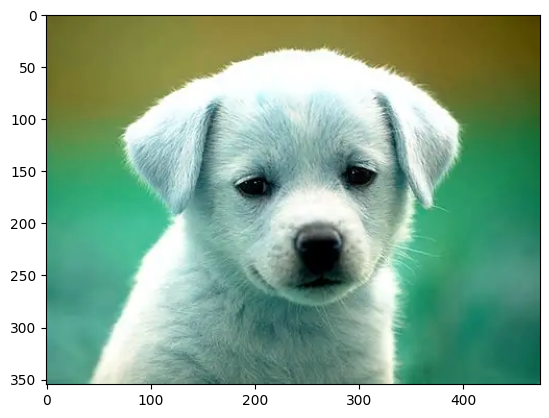

In [ ]:
# Display the test image using matplotlib's imshow() function.
plt.imshow(test_img)

In [ ]:
# Check the dimensions (shape) of the loaded test image.
test_img.shape

(355, 474, 3)

In [ ]:
# Resize the test image to 256x256 pixels using OpenCV's resize() function.
# The model was trained on 256x256 images, so any new image must be resized
# to match this exact input shape before it can be passed to the model.
# cv2.resize(src, (width, height)) — note: OpenCV uses (width, height) order.
test_img = cv2.resize(test_img, (256, 256))

In [ ]:
# Reshape the image array to add a batch dimension.
# The model expects input shape: (batch_size, height, width, channels).
# reshape((1, 256, 256, 3)) converts from (256, 256, 3) to (1, 256, 256, 3),
# where batch_size=1 indicates we are predicting on a single image.
# This extra dimension is required because Keras models always expect batched input.
test_input = test_img.reshape((1, 256, 256, 3))

In [ ]:
# Use the trained model to predict the class of the test image.
# model.predict() returns a probability value between 0 and 1 (sigmoid output):
#   - Values close to 0.0 → the model predicts 'Cat' (class 0)
#   - Values close to 1.0 → the model predicts 'Dog' (class 1)
# Note: The input should be normalized (divided by 255.0) to match training
# preprocessing. Without normalization, predictions may be inaccurate.
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)